In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    default_assay="RNA",
)

Downloading bucket files: 43695338 / 43695338 complete

Downloading bytes: 43695338 / 43695338 complete

In [2]:
multi_sink = ds.run_pseudotime_scoring(
    source_sink_key="clusters",
    sources=["Ductal"],
    sinks=["Alpha", "Beta", "Delta"],
    label="multi_sink_pseudotime",
)

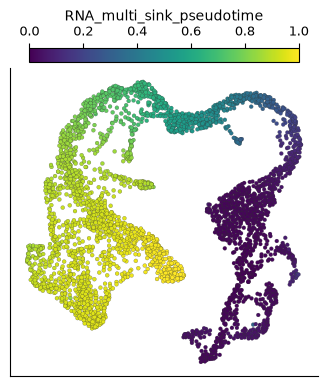

In [3]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=multi_sink.pseudotime_key,
    subset_by=multi_sink.validity_key,
)

In [4]:
beta_sink = ds.run_pseudotime_scoring(
    source_sink_key="clusters",
    sources=["Ductal"],
    sinks=["Beta"],
    label="beta_sink_pseudotime",
)

In [5]:
boundary_results = {
    "Alpha, Beta, and Delta sinks": multi_sink,
    "Beta sink": beta_sink,
}
selected_cells = int(ds.cells.fetch_all("I").sum())
coverage = pd.DataFrame(
    {
        name: {
            "valid cells": int(
                ds.cells.fetch_all(result.validity_key).sum()
            ),
            "valid fraction": float(
                ds.cells.fetch_all(result.validity_key).sum()
                / selected_cells
            ),
        }
        for name, result in boundary_results.items()
    }
).T
coverage

,valid cells,valid fraction
"Alpha, Beta, and Delta sinks",3696.0,1.0
Beta sink,3696.0,1.0


In [6]:
multi_valid = ds.cells.fetch_all(multi_sink.validity_key).astype(bool)
beta_valid = ds.cells.fetch_all(beta_sink.validity_key).astype(bool)
shared_valid = multi_valid & beta_valid
if int(shared_valid.sum()) < 2:
    raise RuntimeError(
        "Boundary comparison needs at least two jointly valid cells"
    )

multi_values = ds.cells.fetch_all(multi_sink.pseudotime_key)
beta_values = ds.cells.fetch_all(beta_sink.pseudotime_key)
rank_agreement = pd.Series(
    multi_values[shared_valid]
).corr(
    pd.Series(beta_values[shared_valid]),
    method="spearman",
)
pd.Series(
    {
        "jointly valid cells": int(shared_valid.sum()),
        "Spearman rank agreement": rank_agreement,
    }
)

jointly valid cells        3696.000000
Spearman rank agreement       0.992889
dtype: float64

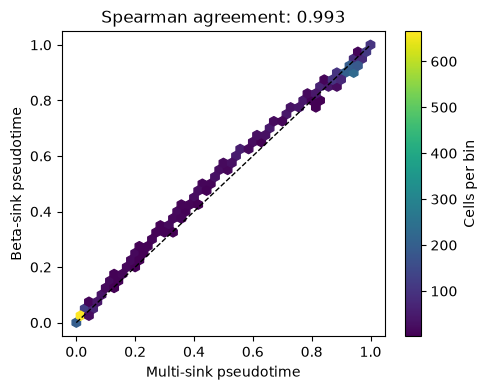

In [7]:
figure, axis = plt.subplots(figsize=(5, 4))
density = axis.hexbin(
    multi_values[shared_valid],
    beta_values[shared_valid],
    gridsize=35,
    mincnt=1,
    cmap="viridis",
)
comparison_min = min(
    multi_values[shared_valid].min(),
    beta_values[shared_valid].min(),
)
comparison_max = max(
    multi_values[shared_valid].max(),
    beta_values[shared_valid].max(),
)
axis.plot(
    [comparison_min, comparison_max],
    [comparison_min, comparison_max],
    color="black",
    linestyle="--",
    linewidth=1,
)
axis.set(
    xlabel="Multi-sink pseudotime",
    ylabel="Beta-sink pseudotime",
    title=f"Spearman agreement: {rank_agreement:.3f}",
)
figure.colorbar(density, ax=axis, label="Cells per bin")
figure.tight_layout()
plt.show()

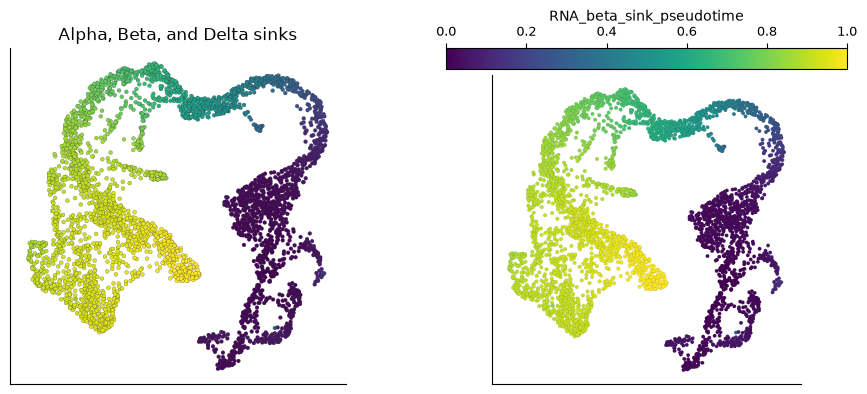

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for index, (axis, (title, result)) in enumerate(
    zip(axes, boundary_results.items(), strict=True)
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=result.pseudotime_key,
        subset_by=result.validity_key,
        show_legend=index == 1,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure

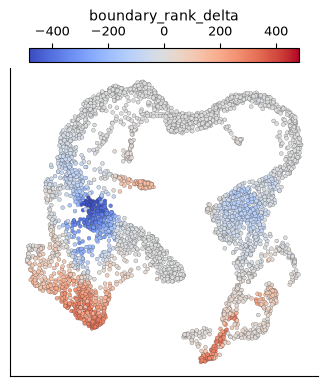

In [9]:
selected = ds.cells.fetch_all("I").astype(bool)
rank_delta = np.full(multi_values.shape[0], np.nan, dtype=float)
rank_delta[shared_valid] = (
    pd.Series(multi_values[shared_valid]).rank(method="average")
    - pd.Series(beta_values[shared_valid]).rank(method="average")
).to_numpy()
ds.cells.insert(
    "boundary_rank_delta",
    rank_delta[selected],
    key="I",
    overwrite=True,
)
ds.cells.insert(
    "boundary_shared_valid",
    shared_valid[selected],
    fill_value=False,
    key="I",
    overwrite=True,
)
rank_limit = float(np.nanmax(np.abs(rank_delta[shared_valid])))
if rank_limit == 0.0:
    rank_limit = 1.0
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="boundary_rank_delta",
    subset_by="boundary_shared_valid",
    color_scale=splt.ColorScale(
        cmap="coolwarm",
        vmin=-rank_limit,
        vmax=rank_limit,
        vcenter=0,
    ),
)

In [10]:
population_summary = pd.DataFrame(
    {
        "population": ds.cells.fetch_all("clusters"),
        "multi-sink pseudotime": np.where(
            multi_valid,
            multi_values,
            np.nan,
        ),
        "Beta-sink pseudotime": np.where(
            beta_valid,
            beta_values,
            np.nan,
        ),
    }
).groupby("population").agg(["count", "median"])
population_summary

multi-sink pseudotime           Beta-sink pseudotime          
                              count    median                count    median
population                                                                  
Alpha                           481  0.943328                  481  0.913190
Beta                            591  0.958881                  591  0.951594
Delta                            70  0.891140                   70  0.868532
Ductal                          916  0.014930                  916  0.017798
Epsilon                         142  0.904743                  142  0.890063
Ngn3 high EP                    642  0.491241                  642  0.546636
Ngn3 low EP                     262  0.035647                  262  0.041382
Pre-endocrine                   592  0.838679                  592  0.853150

In [11]:
markers = ds.run_pseudotime_marker_search(
    cell_key=multi_sink.validity_key,
    pseudotime_key=multi_sink.pseudotime_key,
)

(
    markers.table.loc[
        markers.table["p_value_adjusted"].notna(),
        ["feature_name", "r_value", "p_value", "p_value_adjusted"],
    ]
    .assign(abs_r_value=lambda frame: frame["r_value"].abs())
    .sort_values("abs_r_value", ascending=False)
    .drop(columns="abs_r_value")
    .head(10)
)

Finding correlated features: 1 / 1 complete

,feature_name,r_value,p_value,p_value_adjusted
11497,Rpl13,-0.828517,0.0,0.0
10436,Rps19,-0.821364,0.0,0.0
8979,Spp1,-0.821112,0.0,0.0
7747,Rps8,-0.817098,0.0,0.0
9443,Rpl32,-0.793551,0.0,0.0
12367,Rps4x,-0.793366,0.0,0.0
177,Dbi,-0.788328,0.0,0.0
6533,Rpl12,-0.769530,0.0,0.0
4948,Rps2,-0.756031,0.0,0.0
4993,Rpl10a,-0.753413,0.0,0.0


In [12]:
markers.table[["p_value", "p_value_adjusted"]].isna().sum()

p_value             0
p_value_adjusted    0
dtype: int64

In [13]:
module_results = {}
module_rows = []
for name, n_clusters in {"coarse": 6, "fine": 12}.items():
    result = ds.run_pseudotime_aggregation(
        cell_key=multi_sink.validity_key,
        pseudotime_key=multi_sink.pseudotime_key,
        cluster_label=f"trajectory_modules_{name}",
        n_clusters=n_clusters,
        window_size=200,
        chunk_size=100,
    )
    module_results[name] = result
    assignments = pd.Series(result.feature_clusters)
    module_sizes = assignments[assignments != -1].value_counts()
    module_rows.append(
        {
            "setting": name,
            "requested modules": n_clusters,
            "assigned features": int(module_sizes.sum()),
            "observed modules": int(len(module_sizes)),
            "smallest module": int(module_sizes.min()),
            "largest module": int(module_sizes.max()),
        }
    )
pd.DataFrame(module_rows).set_index("setting")

Binning over cell-ordering: 1 / 1 complete

Fitting feature KNN: 1 / 1 complete

Identifying feature neighbors: 1 / 1 complete

Sorting clusters: 1 / 1 complete

Binning over cell-ordering: 1 / 1 complete

Fitting feature KNN: 1 / 1 complete

Identifying feature neighbors: 1 / 1 complete

Sorting clusters: 1 / 1 complete

,requested modules,assigned features,observed modules,smallest module,largest module
setting,,,,,
coarse,6,12437,6,984,2546
fine,12,12437,12,365,2080


In [14]:
coarse_modules = module_results["coarse"]
fine_modules = module_results["fine"]
module_features = ds.RNA.feats.to_pandas_dataframe(
    [
        "names",
        coarse_modules.cluster_key,
        fine_modules.cluster_key,
    ]
)
assigned_both = module_features[
    (module_features[coarse_modules.cluster_key] != -1)
    & (module_features[fine_modules.cluster_key] != -1)
]
pd.crosstab(
    assigned_both[coarse_modules.cluster_key],
    assigned_both[fine_modules.cluster_key],
    normalize="index",
).round(2)

trajectory_modules_fine,1,2,3,4,5,6,7,8,9,10,11,12
trajectory_modules_coarse,,,,,,,,,,,,
1,1.0,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00
2,0.0,0.31,0.5,0.19,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00
3,0.0,0.00,0.0,0.00,0.34,0.26,0.4,0.00,0.00,0.0,0.00,0.00
4,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.49,0.51,0.0,0.00,0.00
5,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,1.0,0.00,0.00
6,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.82,0.18


coarse modules (trajectory_modules_coarse)


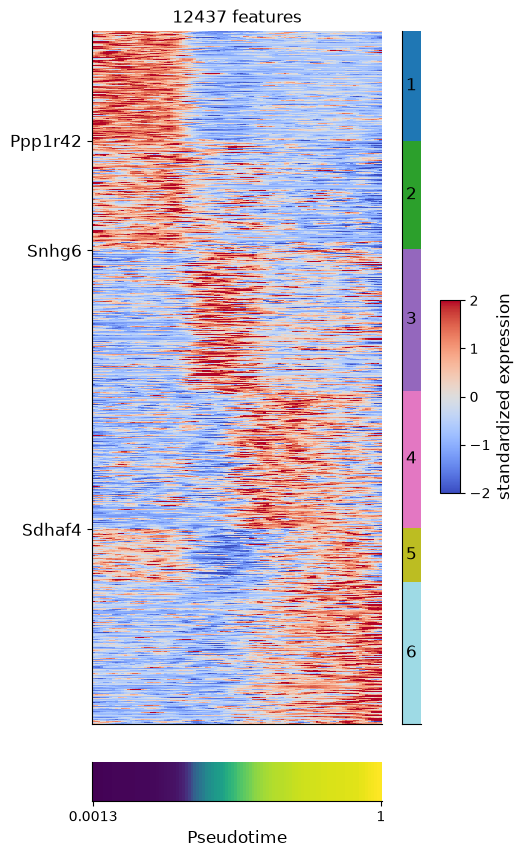

fine modules (trajectory_modules_fine)


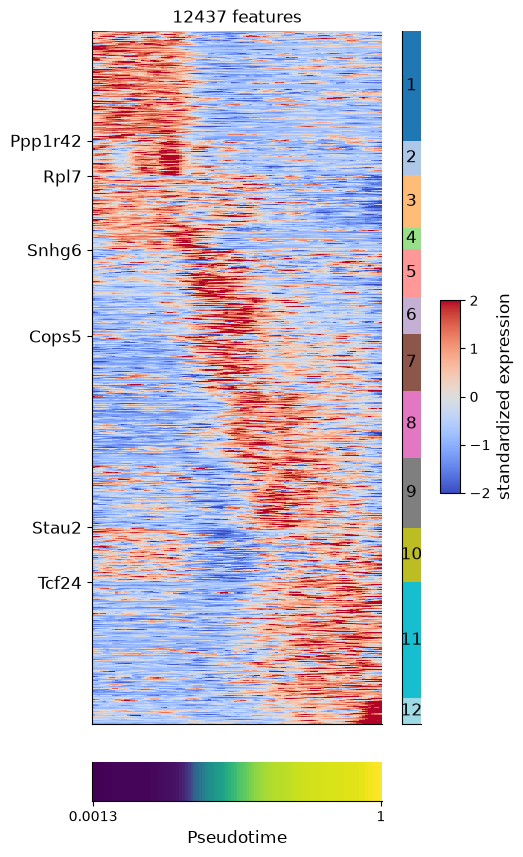

In [15]:
for name, modules in module_results.items():
    assigned = module_features[
        module_features[modules.cluster_key] != -1
    ]
    representatives = (
        assigned.groupby(modules.cluster_key, sort=True)["names"]
        .first()
    )
    labels = representatives.iloc[::2].tolist()
    print(f"{name} modules ({modules.cluster_key})")
    ds.plots.pseudotime_heatmap(
        cell_key=modules.cell_key,
        feat_key=modules.feature_key,
        feature_cluster_key=modules.cluster_key,
        pseudotime_key=modules.pseudotime_key,
        show_features=labels,
    )

In [16]:
modules = fine_modules
assigned = module_features[
    module_features[modules.cluster_key] != -1
]
ds.run_marker_search(group_key="clusters")
beta_markers = set(
    ds.get_markers(group_key="clusters", group_id="Beta").feature_name
)
module_overlap = (
    assigned.groupby(modules.cluster_key)["names"]
    .apply(lambda names: len(set(names) & beta_markers))
    .sort_values(ascending=False)
)
module_overlap.head()

trajectory_modules_fine
11    53
12    49
7      8
9      6
8      1
Name: names, dtype: int64

In [17]:
fate = ds.run_fate_mapping(
    cell_key="I",
    subset_cell_key=multi_sink.validity_key,
    pseudotime_key=multi_sink.pseudotime_key,
    sink_key="clusters",
    sinks=["Alpha", "Beta", "Delta"],
)

valid_probabilities = fate.values[fate.valid]
simplex_error = float(
    np.max(np.abs(valid_probabilities.sum(axis=1) - 1.0))
)
simplex_error

1.1920928955078125e-07

In [18]:
selected_labels = ds.cells.fetch(
    fate.sink_key,
    key=fate.result_cell_key,
)
terminal_checks = []
for index, sink in enumerate(fate.sink_labels):
    rows = (selected_labels == sink) & fate.valid
    terminal_checks.append(
        {
            "sink": sink,
            "cells": int(rows.sum()),
            "minimum own probability": float(
                fate.values[rows, index].min()
            ),
        }
    )
pd.DataFrame(terminal_checks)

,sink,cells,minimum own probability
0,Alpha,481,1.0
1,Beta,591,1.0
2,Delta,70,1.0


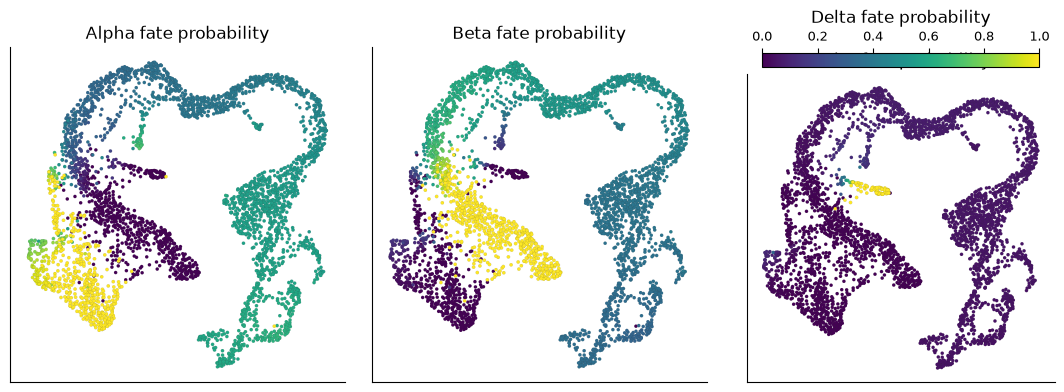

In [19]:
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
probability_scale = splt.ColorScale(vmin=0, vmax=1)
for index, (axis, sink, fate_key) in enumerate(
    zip(axes, fate.sink_labels, fate.fate_keys, strict=True)
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=fate_key,
        subset_by=fate.validity_key,
        color_scale=probability_scale,
        sort_values=True,
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(f"{sink} fate probability")
for colorbar_axis in set(figure.axes) - set(axes):
    colorbar_axis.set_title(f"{fate.sink_labels[-1]} fate probability")
    colorbar_axis.set_xlabel("")
    colorbar_axis.set_ylabel("")
figure.tight_layout()
figure

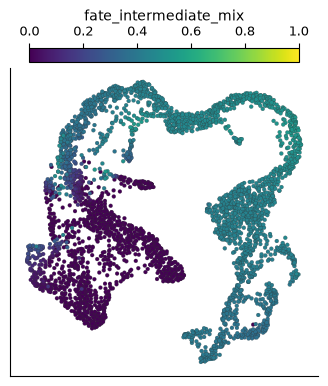

In [20]:
mix_values = np.full(len(fate.valid), np.nan, dtype=float)
mix_values[fate.valid] = 1.0 - fate.values[fate.valid].max(axis=1)
ds.cells.insert(
    "fate_intermediate_mix",
    mix_values,
    key=fate.result_cell_key,
    overwrite=True,
)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="fate_intermediate_mix",
    subset_by=fate.validity_key,
    color_scale=splt.ColorScale(vmin=0, vmax=1),
    sort_values=True,
)